<a href="https://colab.research.google.com/github/kulikovssskaya/ml-portfolio/blob/main/%D0%9E%D1%81%D0%BD%D0%BE%D0%B2%D1%8B_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практические задания (код)

Подготовим всё для загрузки набора данных.

Установка библиотек.

In [2]:
!pip install pingouin fastexcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 89.9 MB/s eta 0:00:00


Импорт необходимых библиотек

In [3]:
import numpy as np
import pandas as pd
import polars as pl

import pingouin as pg

import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

In [4]:
source = "https://raw.githubusercontent.com/m-ardat/StatisticsForEveryone/refs/heads/main/data/RosstatAveragePricesOneSqM.xlsx"
df = pl.read_excel(source=source)

df.head(4)

region,new_building_2025,resale_home_2025,new_building_2024,resale_home_2024,new_building_2023,resale_home_2023,new_building_2022,resale_home_2022,new_building_2021,resale_home_2021
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""Город Москва""",433182.38,371970.43,352661.15,320317.02,340836.76,328063.88,374658,297454,299031,251014
"""Центральный федеральный округ""",313820.14,165406.37,239843.84,120563.11,193421.96,93246.58,135667,119041,117075,98407
"""Город Санкт-Петербург""",293609.01,276184.86,276328.83,220961.8,222717.19,178339.9,231245,158517,184667,167211
"""Чукотский автономный округ""",269900.81,null,246224.42,null,155441.58,null,null,null,null,null


Данный набор данных содержит средние цены 1 кв. м. общей площади квартир на первичном и вторичном рынках жилья по Российской Федерации и субъектам Российской Федерации ([Источник](https://bi.rosstat.gov.ru/biportal/contourbi.jsp?allsol=1&solution=Dashboard&project=%2FDashboard%2Fhousing_market_price_statistics))

Здесь представлены средние цены 1 кв. м. новостроек (`new_building`) и вторичек (`resale_home`) с 2021 года по 2025 год.

**Задание №1**. Рассчитайте среднюю стоимость 1 м² в новостройках Калининградской области (`"Калининградская область"`) за период 2021-2025 гг. Ответ округлите до сотых.

In [12]:
# Пишите код здесь
result = (
    df.filter(pl.col('region') == 'Калининградская область')
    .select(
        pl.col('new_building_2021').mean(),
        pl.col('new_building_2022').mean(),
        pl.col('new_building_2023').mean(),
        pl.col('new_building_2024').mean(),
        pl.col('new_building_2025').mean()
    )
)
val = result.select(pl.mean_horizontal(pl.all())).item()

print(round(val,2))


107881.49


**Задание №2**. Рассчитайте медианную стоимость (по всем записям) 1 м² вторички за 2024 год. Ответ округлите до целого числа.

In [16]:
# Пишите код здесь
# ...
print(round(df.select('resale_home_2024').median().item(),0))

96826.0


**Задание №3**. Постройте график распределения (по всем записям) цен по новостройкам за 2025 год за 1 м².

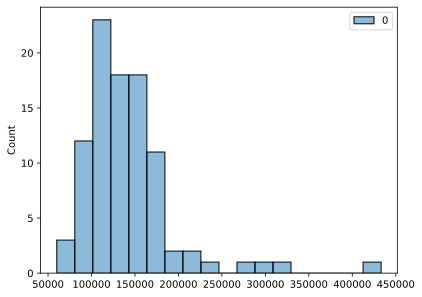

In [18]:
sns.histplot(df.select('new_building_2025'));

**Задание №4**. Рассчитайте межквартильный размах $IQR$ стоимости 1 м² в новостройках за 2025 год (по всем записям). Найдите значения $Q1$, $Q2$, $Q3$. Нанесите эти значения на график из задания №3.

В качестве ответа запишите значения $IQR$. Ответ округлите до целого.

**Примечание**. При расчете квартилей используем метод интерполяции `"midpoint"`.

47745


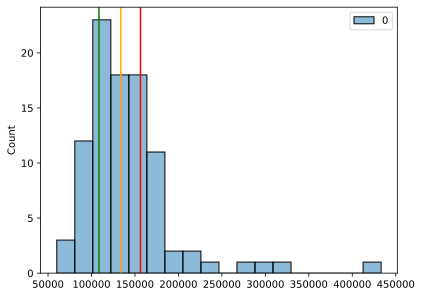

In [25]:
q1 = df.select('new_building_2025').quantile(0.25,interpolation = 'midpoint').item()
q2 = df.select('new_building_2025').quantile(0.5,interpolation = 'midpoint').item()
q3 = df.select('new_building_2025').quantile(0.75,interpolation = 'midpoint').item()

iqr=q3-q1
print(round(iqr))

sns.histplot(df.select('new_building_2025'));

plt.axvline(q1,color='green');
plt.axvline(q2,color='orange');
plt.axvline(q3,color='red');

**Задание №5**. Постройте ящик с усами для стоимости 1 м² в новостройках за 2025 год (по всем записям). Сколько выбросов обнаружено по правилу $1.5×IQR$? Запишите количество.


5


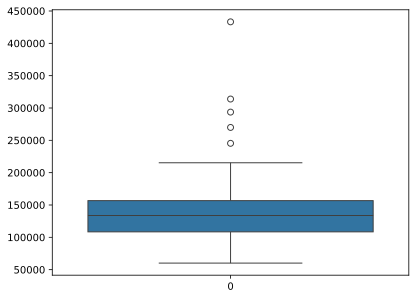

In [30]:
sns.boxplot(df.select('new_building_2025'));
print(len(df.filter(pl.col('new_building_2025')>=q3+1.5*iqr)))

**Задание №6**.  Рассчитайте несмещённую оценку стандартного отклонения стоимости 1 м² в новостройках Сахалинской области (`"Сахалинская область"`) за период 2021-2025 гг. Ответ округлите до сотых.

Что говорит полученное значение о стабильности цен в регионе?

In [36]:
df_filt = df.filter(pl.col('region')=='Сахалинская область')

years_cols = [
    'new_building_2021',
    'new_building_2022',
    'new_building_2023',
    'new_building_2024',
    'new_building_2025',
]

for_std = df_filt.select(years_cols).to_numpy().flatten()

print(round(pl.Series(for_std).std(),2))

19465.41


**Задание №7**. Рассчитайте коэффициент корреляции Пирсона между стоимостью 1 м² в новостройках в 2021 и 2025 годах. Используйте только те регионы (записи), где данные присутствуют за оба года.
Вопросы:
Чему равен коэффициент корреляции Пирсона? Ответ округлите до сотых.
Сохраняют ли регионы свои позиции в ценовом рейтинге?

In [41]:
df_filt = df.drop_nulls(subset='region')

corr_value = df_filt.select(
    pl.corr('new_building_2021', 'new_building_2025')
).item()

print(round(corr_value,2))

0.93
